# REDES NEURONALES
---

En este notebook vamos a utilizar una red neuronal para clasificar imágenes de dígitos escritos a mano. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es MNIST, un problema sencillo con imágenes en escala de grises de dígitos escritos a mano. Puedes consultar más información sobre el dataset en [este enlace](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/).

El código utilizado en el Notebook permitirá comprender varios aspectos relacionados con los datos de entrenamiento y las redes neuronales artificiales, especificamente Fully conected layer network.
1. Información básica del dataset
2. Creación del primer modelo
3. Predicciones y métricas del primer modelo
4. Funciones de activación
5. Inicialización de parámetros
6. Optimizadores
7. Impacto al variar el número de neuronas en las capas ocultas
8. Aumento de épocas y su efecto en la red neuronal
9. *Early stop*

In [ ]:
# La siguiente semilla se va a utilizar en el notebook, para que los resultados se puedan replicar
seed = 42

import numpy as np
import tensorflow as tf
from tensorflow import keras

# Set seeds before importing Keras and other libraries
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1787704144.715688  136955 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787704145.490893  136955 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
print(tf.__version__)

2.21.0


In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

En primer lugar vamos a importar el *dataset **MNIST*** (este dataset de entrenamiento se encuentra en la librería *keras*) que es el que vamos a utilizar en este notebook

In [ ]:
mnist = tf.keras.datasets.mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen las prendas de vestir y sus etiquetas.

Nota: Aunque en esta actividad se ve de esta forma, también se puede encontrar como 4 variables:

```
# Esto tiene formato de código
X_train, y_train, X_test, y_test = mnist.load_data()
```




In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

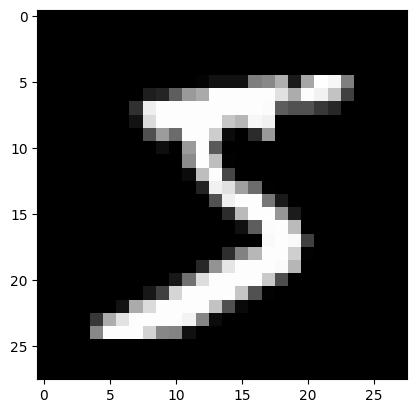

In [ ]:
import numpy as np
np.set_printoptions(linewidth=200)
import matplotlib.pyplot as plt
# Es preferible trabajar en blanco y negro
plt.imshow(X_train[0], cmap="gray")
print(y_train[0])
print(X_train[0])

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.


¿Cuántas imágenes hay en *X_train* y de *X_test*? ¿Qué tamaño tienen las imágenes?

In [ ]:
print(f'Número de imagenes de entrenamiento {X_train.shape[0]}\nNúmero de imagenes de prueba {X_test.shape[0]}')

Número de imagenes de entrenamiento 60000
Número de imagenes de prueba 10000


Realizar una exploración de las variables que contienen los datos. Describir qué información se guarda en cada imagen y qué contiene la información en *y_train*.

In [ ]:
print(y_train[0])

5


# Preprocesamiento

Se puede notar que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena práctica es transformar todos los valores entre 0 y 1. A este proceso se le conoce como "normalización".

En Python es fácil normalizar una lista, y se puede hacer de la siguiente manera:

In [ ]:
X_train  = X_train / 255.0
X_test = X_test / 255.0

## 2. Creación del Modelo

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función **Relu** en las capas ocultas y ***softmax*** en la ultima capa (en problemas de clasificación de más de dos clases)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 Utilizando *Keras*, y preparando los datos de X e y como fuera necesario, se define y entrena una red neuronal que sea capaz de clasificar imágenes de **MNIST** con las siguientes características:

* Una hidden layer de 128 neuronas y función de activación *sigmoid*.
* La capa de salida debe ser *softmax*.
* El algoritmo de optimización debe ser *Adam*.
* La red debe entrenarse durante 10 *epochs*, con un *batch size* de 64.
* Usar la semilla durante el entrenamiento
* Durante el entrenamiento, la red tiene que mostrar resultados de loss y accuracy por cada epoch.

A partir de las características anteriores, **la red superará fácilmente el 80% de *accuracy***.


In [ ]:
### Definición de la arquitectura de la red ###
model_128 = Sequential()
# Se define el tamaño de datos que va a entrar a la red neuronal
model_128.add(Input(shape=(28, 28)))
# Convierte la imagen, arreglo bidimensional, en un vector unidimensional
model_128.add(Flatten())
# Capa oculta
model_128.add(Dense(128, activation='sigmoid'))
# Capa de salida
model_128.add(Dense(10, activation='softmax'))

In [ ]:
### Configuración del proceso de aprendizaje del modelo ###
model_128.compile(
    # Optimizador
    optimizer = 'Adam',
    # Función de perdida
    loss = 'sparse_categorical_crossentropy',
    # Métrica para evaluar el rendimiento
    metrics=['accuracy'])

In [ ]:
### Entrenamiento del modelo ###
history_128 = model_128.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 10,
    batch_size = 64)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8698 - loss: 0.5229 - val_accuracy: 0.9242 - val_loss: 0.2747
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9274 - loss: 0.2567 - val_accuracy: 0.9397 - val_loss: 0.2135
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9429 - loss: 0.2002 - val_accuracy: 0.9488 - val_loss: 0.1801
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9524 - loss: 0.1640 - val_accuracy: 0.9552 - val_loss: 0.1576
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9603 - loss: 0.1379 - val_accuracy: 0.9590 - val_loss: 0.1411
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9667 - loss: 0.1178 - val_accuracy: 0.9632 - val_loss: 0.1286
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9715 - loss: 0.1017 - val_accuracy: 0.9662 - val_loss: 0.1190
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9758 - loss: 0.0885 - val_accuracy: 0.

Para concluir el entrenamiento de la red neuronal, una buena practica es verificar como se comportan las métricas a lo largo del entrenamiento de manera gráfica. Además, evaluar el modelo para ver si la precisión de entrenamiento es real

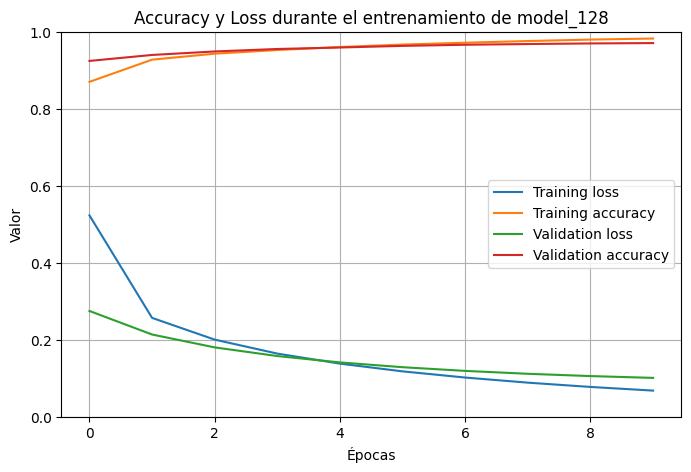

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_128.history['loss'], label='Training loss')
plt.plot(history_128.history['accuracy'], label='Training accuracy')
plt.plot(history_128.history['val_loss'], label='Validation loss')
plt.plot(history_128.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy y Loss durante el entrenamiento de model_128')
plt.xlabel('Épocas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)  # Se pone el límite del eje 'y' entre 0 y 1
plt.show()

Evaluación del modelo con las imágenes del conjunto de entrenamiento, *X_train*. Posteriormente, se evaluan las imágenes del conjunto de prueba, *X_test*.

In [ ]:
### Evaluación de la red neuronal ###
eval_train = model_128.evaluate(X_train, y_train)
eval_test = model_128.evaluate(X_test, y_test)

print(f'El accuracy y loss del conjunto de entrenamiento son: {eval_train[1]} y {eval_train[0]}')
print(f'El accuracy y loss del conjunto de prueba son: {eval_test[1]} y {eval_test[0]}')

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - accuracy: 0.9829 - loss: 0.0661
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.9736 - loss: 0.0913
El accuracy y loss del conjunto de entrenamiento son: 0.9829000234603882 y 0.06612291187047958
El accuracy y loss del conjunto de prueba son: 0.9735999703407288 y 0.09129113703966141


Ahora vamos a explorar el código con una serie de ejercicios para alcanzar un grado de comprensión mayor sobre las redes neuronales y su entrenamiento.

## 3: Predicciones y métricas de la red neuronal

Los siguientes pasos de esta sección son:

* Se crea una variable llamada **y_predict** para construir un clasificador con las imágenes de prueba, para ello puedes utilizar la función **predict** sobre el conjunto de test
* Se imprime el reporte de métricas


In [ ]:
### Se realizan las predicciones ###
y_predict = model_128.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step


In [ ]:
y_pred = []
for i in range(y_predict.shape[0]):
    maximum = np.argmax(y_predict[i])
    y_pred.append(maximum)

In [ ]:
# Vector de predicciones
print('Vector de probabilidades')
print(y_predict[0])
# Clase predicha
print(f'Predicción final: {y_pred[0]}\tClase correcta: {y_test[0]}')

Vector de probabilidades
[1.5392595e-06 1.2897034e-06 3.5065776e-05 6.2881899e-04 1.9115946e-07 2.0206269e-06 1.5882428e-09 9.9928087e-01 6.9849381e-07 4.9449871e-05]
Predicción final: 7	Clase correcta: 7


In [ ]:
### Reporte de métricas ###
vector = np.array(y_test)
class_names = [ str(x) for x in np.unique(vector) ]

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Funciones

In [ ]:
def get_last_metrics(dict_hist):
    lst_met = []
    lst_cols = []
    for key, value in dict_hist.items():
        lst_met.append(value[-1])
        lst_cols.append(key)
    return lst_met, lst_cols

In [ ]:
def get_df_metrics(lst_hist, lst_item):
    df_met = pd.DataFrame()
    for func, hist in zip(lst_item, lst_hist):
        lst_met, lst_cols = get_last_metrics(hist)
        df_aux = pd.DataFrame([lst_met], columns=lst_cols)
        df_aux.insert(loc=0, column='activation function', value=[func])
        df_met = pd.concat([df_met, df_aux])
    df_met.reset_index(drop=True, inplace=True)
    return df_met

## 4. Unidades de activación

En este ejercicio, se va a evaluar la importancia de utilizar las unidades de activación adecuadas.

Definir 3 modelos, los cuales tendrán la siguiente arquitectura:

* Tres *hidden layers* de:
    1. 300 neuronas
    2. 200 neuronas
    3. 100 neuronas
* La capa de salida debe ser *softmax*.
* El algoritmo de optimización debe ser *Adam*.
* La red debe entrenarse durante 10 *epochs*, con un *batch size* de 64.
* Usar la semilla durante el entrenamiento
* Durante el entrenamiento, la red tiene que mostrar resultados de loss y accuracy por cada epoch.

El primer modelo debe usar la función de activación *sigmoid* en las capas ocultas. En el segundo, se debe emplear la función de activación *tanh*, mientras que el tercer modelo, debe usar la función de activación "ReLU".

In [ ]:
def train_model_actf(optimizer, act_f, X_train, y_train):
    model = Sequential()
    model.add(Input(shape=(28, 28)))
    model.add(Flatten())
    model.add(Dense(300, activation = act_f))
    model.add(Dense(200, activation = act_f))
    model.add(Dense(100, activation = act_f))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer = optimizer,
        loss = 'sparse_categorical_crossentropy',
        metrics=['accuracy']
        )

    history = model.fit(
        X_train, y_train,
        validation_split = 0.2,
        epochs = 10,
        batch_size = 64
    )

    return model, history

In [ ]:
optimizer = 'Adam'
lst_factivation = ['tanh', 'sigmoid', 'relu']
lst_style = ['--', ':', '-']

In [ ]:
dict_actfmodels = {}
for f_act in lst_factivation:
    print(f'Modelo con función de activación {f_act}')
    model_, history_ = train_model_actf(optimizer, f_act, X_train, y_train)
    dict_actfmodels[f_act] = [model_, history_]

Modelo con función de activación tanh
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9203 - loss: 0.2680 - val_accuracy: 0.9508 - val_loss: 0.1612
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9611 - loss: 0.1274 - val_accuracy: 0.9626 - val_loss: 0.1241
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9750 - loss: 0.0848 - val_accuracy: 0.9693 - val_loss: 0.1066
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9836 - loss: 0.0573 - val_accuracy: 0.9722 - val_loss: 0.1025
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9883 - loss: 0.0420 - val_accuracy: 0.9741 - val_loss: 0.0978
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9904 - loss: 0.0320 - val_accuracy: 0.9657 - val_loss: 0.1256
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9912 - loss: 0.0281 - val_accuracy: 0.9717 - val_loss: 0.1076
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.

In [ ]:
lst_hist_models = []
for key in dict_actfmodels:
    mod = dict_actfmodels[key]
    hist = mod[1]
    lst_hist_models.append(hist.history)

In [ ]:
df_met_actf = get_df_metrics(lst_hist_models, lst_factivation)
display(df_met_actf)

,activation function,accuracy,loss,val_accuracy,val_loss
0,tanh,0.995146,0.015290,0.973083,0.119043
1,sigmoid,0.994083,0.024174,0.969833,0.117872
2,relu,0.993854,0.019010,0.974083,0.116634


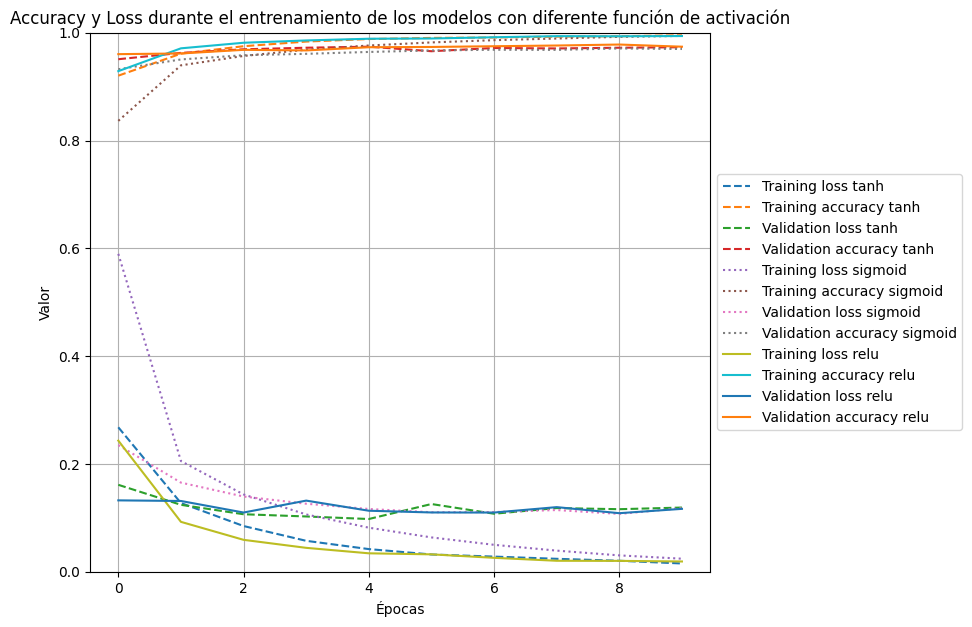

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(111)

for fact, hist, sline in zip(lst_factivation, lst_hist_models, lst_style):
    ax.plot(hist['loss'], label=f'Training loss {fact}', linestyle = sline)
    ax.plot(hist['accuracy'], label=f'Training accuracy {fact}', linestyle = sline)
    ax.plot(hist['val_loss'], label=f'Validation loss {fact}', linestyle = sline)
    ax.plot(hist['val_accuracy'], label=f'Validation accuracy {fact}', linestyle = sline)

plt.grid(True)
plt.ylim(0, 1)  # Coloca los límites del eje y entre 0 y 1

plt.title('Accuracy y Loss durante el entrenamiento de los modelos con diferente función de activación')
plt.xlabel('Épocas')
plt.ylabel('Valor')

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## 5. Inicialización de parámetros

En este apartado, se va a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

Partiendo de una red similar a la inicial y usando la función de activación *ReLU*. Inicializar los parámetros con las siguientes estrategias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

In [ ]:
from keras.initializers import Zeros, GlorotUniform, RandomNormal

In [ ]:
model_zeros = Sequential()
model_zeros.add(Input(shape=(28, 28)))
model_zeros.add(Flatten())
model_zeros.add(Dense(128, activation='relu', kernel_initializer=Zeros()))
model_zeros.add(Dense(10, activation='softmax', kernel_initializer=Zeros()))

model_zeros.compile(optimizer='adam',
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])

history_zeros = model_zeros.fit(X_train, y_train,
                           epochs=10,
                           batch_size=64,
                           validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1138 - loss: 2.3016 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.

In [ ]:
model_glorot = Sequential([
    Flatten(input_shape = (28, 28)),
    Dense(128, activation = 'relu', kernel_initializer = GlorotUniform()),
    Dense(10, activation = 'softmax', kernel_initializer = GlorotUniform())
])

model_glorot.compile(optimizer='adam',
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])

history_glorot = model_glorot.fit(X_train, y_train,
                           epochs=10,
                           batch_size=64,
                           validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9054 - loss: 0.3325 - val_accuracy: 0.9485 - val_loss: 0.1804
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9551 - loss: 0.1565 - val_accuracy: 0.9596 - val_loss: 0.1341
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9679 - loss: 0.1095 - val_accuracy: 0.9643 - val_loss: 0.1164
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.0830 - val_accuracy: 0.9666 - val_loss: 0.1064
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9817 - loss: 0.0650 - val_accuracy: 0.9694 - val_loss: 0.1000
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9862 - loss: 0.0516 - val_accuracy: 0.9713 - val_loss: 0.0943
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9894 - loss: 0.0409 - val_accuracy: 0.9728 - val_loss: 0.0896
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9920 - loss: 0.0326 - val_accuracy: 0.

In [ ]:
model_random = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu', kernel_initializer=RandomNormal()),
    Dense(10, activation='softmax', kernel_initializer=RandomNormal())
])

model_random.compile(optimizer='adam',
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])

history_random = model_random.fit(X_train, y_train,
                           epochs=10,
                           batch_size=64,
                           validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8992 - loss: 0.3708 - val_accuracy: 0.9429 - val_loss: 0.1999
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9507 - loss: 0.1714 - val_accuracy: 0.9559 - val_loss: 0.1508
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9649 - loss: 0.1224 - val_accuracy: 0.9605 - val_loss: 0.1283
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9730 - loss: 0.0936 - val_accuracy: 0.9647 - val_loss: 0.1165
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0740 - val_accuracy: 0.9677 - val_loss: 0.1075
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9836 - loss: 0.0594 - val_accuracy: 0.9695 - val_loss: 0.1027
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0480 - val_accuracy: 0.9700 - val_loss: 0.0998
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9907 - loss: 0.0388 - val_accuracy: 0.

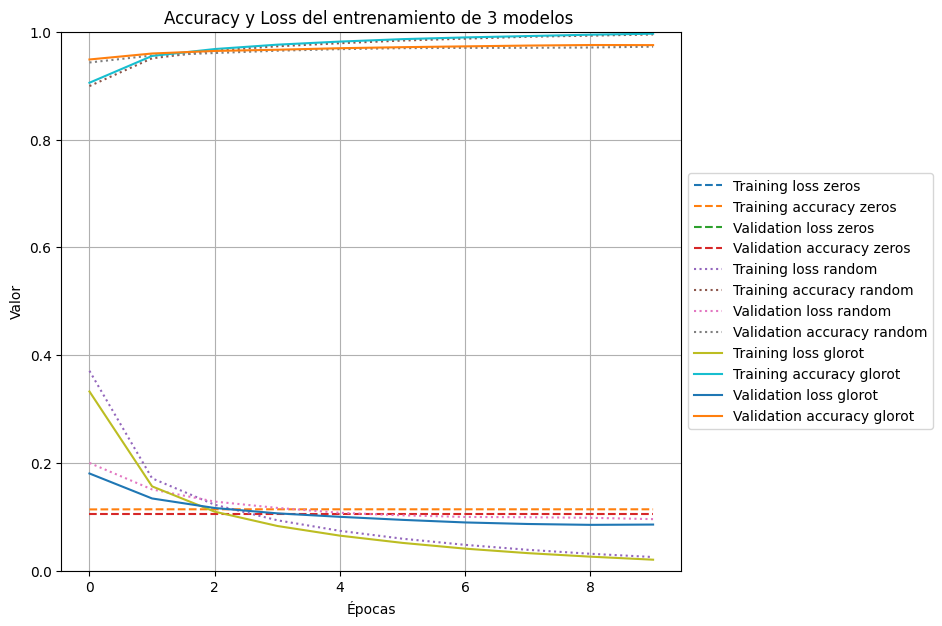

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(111)

ax.plot(history_zeros.history['loss'], label='Training loss zeros', linestyle='--')
ax.plot(history_zeros.history['accuracy'], label='Training accuracy zeros', linestyle='--')
ax.plot(history_zeros.history['val_loss'], label='Validation loss zeros', linestyle='--')
ax.plot(history_zeros.history['val_accuracy'], label='Validation accuracy zeros', linestyle='--')
ax.plot(history_random.history['loss'], label='Training loss random', linestyle=':')
ax.plot(history_random.history['accuracy'], label='Training accuracy random', linestyle=':')
ax.plot(history_random.history['val_loss'], label='Validation loss random', linestyle=':')
ax.plot(history_random.history['val_accuracy'], label='Validation accuracy random', linestyle=':')
ax.plot(history_glorot.history['loss'], label='Training loss glorot', linestyle='-')
ax.plot(history_glorot.history['accuracy'], label='Training accuracy glorot', linestyle='-')
ax.plot(history_glorot.history['val_loss'], label='Validation loss glorot', linestyle='-')
ax.plot(history_glorot.history['val_accuracy'], label='Validation accuracy glorot', linestyle='-')

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Accuracy y Loss del entrenamiento de 3 modelos ')
plt.xlabel('Épocas')
plt.ylabel('Valor')
plt.grid(True)
plt.ylim(0, 1)  # Coloca los límites del eje y entre 0 y 1
plt.show()

## 6. Optimizadores

En este apartado, se va a evaluar la importancia del optimizador que se emplea en el proceso de optimización de parámetros durante el entrenamiento de una red neuronal.

Partiendo de la arquitectura del primer modelo, comparar y analizar las diferencias que se observan al entrenar con varios de optimizadores, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de:

* Ada
* RMSProp
* Adam

Dejar los valores de los parámetros por defecto provistos por Keras para cada optimizador.

In [ ]:
def train_model_opt(optimizer, act_f, X_train, y_train):
    model = Sequential()
    model.add(Input(shape=(28, 28)))
    model.add(Flatten())
    model.add(Dense(128, activation = act_f))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer = optimizer,
        loss = 'sparse_categorical_crossentropy',
        metrics=['accuracy']
        )

    history = model.fit(
        X_train, y_train,
        validation_split = 0.2,
        epochs = 10,
        batch_size = 64
    )
    return model, history

In [ ]:
lst_optimizadores = ['sgd', 'Adagrad', 'RMSprop', 'Adam']
act_function = 'relu'
lst_style_opt = ['--', ':', '-', '-.']

In [ ]:
dict_optmodels = {}
for opt in lst_optimizadores:
    print(f'Modelo con método de optimización {opt}')
    model_, history_ = train_model_opt(opt, act_function, X_train, y_train)
    dict_optmodels[opt] = [model_, history_]

Modelo con método de optimización sgd
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7604 - loss: 0.9963 - val_accuracy: 0.8778 - val_loss: 0.5029
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8792 - loss: 0.4610 - val_accuracy: 0.9003 - val_loss: 0.3778
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8956 - loss: 0.3803 - val_accuracy: 0.9094 - val_loss: 0.3332
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9045 - loss: 0.3422 - val_accuracy: 0.9154 - val_loss: 0.3076
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9112 - loss: 0.3175 - val_accuracy: 0.9201 - val_loss: 0.2896
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9160 - loss: 0.2990 - val_accuracy: 0.9240 - val_loss: 0.2756
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9204 - loss: 0.2839 - val_accuracy: 0.9267 - val_loss: 0.2638
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.

In [ ]:
lst_hist_optm = []
for key in dict_optmodels:
    mod = dict_optmodels[key]
    hist = mod[1]
    lst_hist_optm.append(hist.history)

In [ ]:
df_met_opt = get_df_metrics(lst_hist_optm, lst_optimizadores)
display(df_met_opt)

,activation function,accuracy,loss,val_accuracy,val_loss
0,sgd,0.929875,0.249533,0.933833,0.236153
1,Adagrad,0.892979,0.411449,0.905333,0.376801
2,RMSprop,0.992875,0.029033,0.973917,0.106795
3,Adam,0.996375,0.019668,0.974167,0.088818


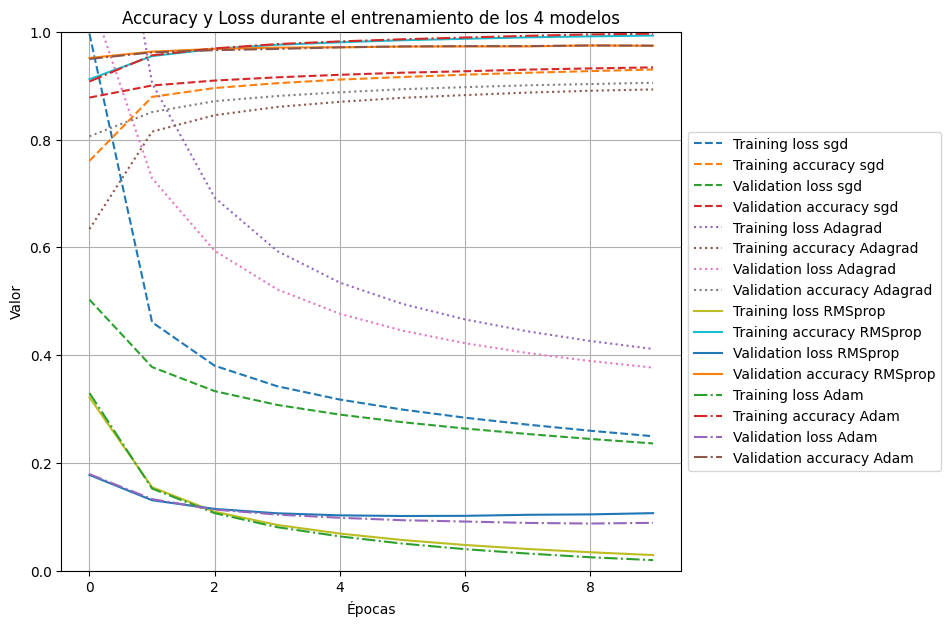

In [ ]:
fig_opt = plt.figure(figsize=(10, 7))
ax_opt = plt.subplot(111)

for opt, hist, sline in zip(lst_optimizadores, lst_hist_optm, lst_style_opt):
    ax_opt.plot(hist['loss'], label=f'Training loss {opt}', linestyle = sline)
    ax_opt.plot(hist['accuracy'], label=f'Training accuracy {opt}', linestyle = sline)
    ax_opt.plot(hist['val_loss'], label=f'Validation loss {opt}', linestyle = sline)
    ax_opt.plot(hist['val_accuracy'], label=f'Validation accuracy {opt}', linestyle = sline)

plt.grid(True)
plt.ylim(0, 1)  # Coloca los límites del eje 'y' entre 0 y 1

plt.title(f'Accuracy y Loss durante el entrenamiento de los {len(lst_optimizadores)} modelos')
plt.xlabel('Épocas')
plt.ylabel('Valor')

# Shrink current axis by 20%
box_opt = ax_opt.get_position()
ax_opt.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax_opt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

# **7: Impacto al variar el número de neuronas en las capas ocultas**

Define una arquitectura con las siguientes caracteristicas:

1. Una capa oculta con 128 neuronas, con función de activación ReLU
3. Método de optimización RMSProp

Adicional, define 2 modelos más con 512 y 1024 neuronas en su capa oculta.

Calcular la matriz de confusión de cada modelo e indica el comportamiento de los números 3 y 8

In [ ]:
def train_model_neu(optimizer, neu, X_train, y_train):
    model = Sequential()
    model.add(Input(shape=(28,28)))
    model.add(Flatten())
    model.add(Dense(neu, activation = 'relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer = optimizer,
        loss = 'sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_split = 0.2,
        epochs = 10,
        batch_size = 64
    )
    return model, history

In [ ]:
optimizer = 'RMSprop'
lst_neuronas = [128, 512, 1024]
lst_style_nneu = ['--', ':', '-']

In [ ]:
dict_nneumodels = {}
for nneu in lst_neuronas:
    print(f'Modelo con {nneu} neuronas en la capa oculta')
    model_, history_ = train_model_neu(optimizer, nneu, X_train, y_train)
    dict_nneumodels[nneu] = [model_, history_]

Modelo con 128 neuronas en la capa oculta
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9111 - loss: 0.3233 - val_accuracy: 0.9505 - val_loss: 0.1779
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9547 - loss: 0.1557 - val_accuracy: 0.9630 - val_loss: 0.1301
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9681 - loss: 0.1100 - val_accuracy: 0.9669 - val_loss: 0.1120
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0847 - val_accuracy: 0.9688 - val_loss: 0.1033
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9812 - loss: 0.0682 - val_accuracy: 0.9694 - val_loss: 0.1003
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9849 - loss: 0.0562 - val_accuracy: 0.9700 - val_loss: 0.0985
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0469 - val_accuracy: 0.9714 - val_loss: 0.0970
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

In [ ]:
lst_hist_nneu = []
for key in dict_nneumodels:
    mod = dict_nneumodels[key]
    hist = mod[1]
    lst_hist_nneu.append(hist.history)

In [ ]:
df_met_nneu = get_df_metrics(lst_hist_nneu, lst_neuronas)
display(df_met_nneu)

,activation function,accuracy,loss,val_accuracy,val_loss
0,128,0.993250,0.028296,0.974083,0.095456
1,512,0.999083,0.004794,0.978250,0.092396
2,1024,0.999333,0.003136,0.979833,0.096512


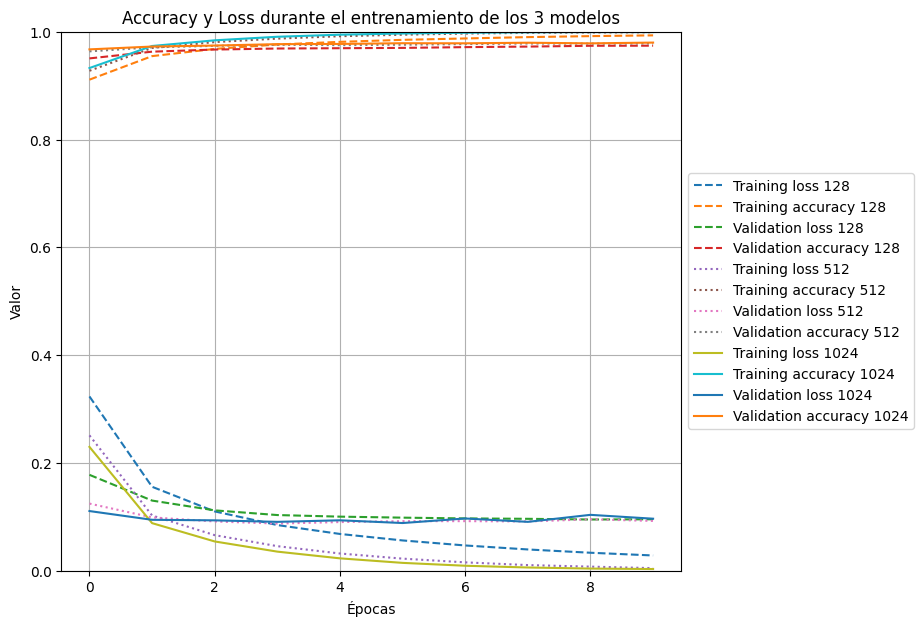

In [ ]:
fig_nneu = plt.figure(figsize=(10, 7))
ax_nneu = plt.subplot(111)

for nneu, hist, sline in zip(lst_neuronas, lst_hist_nneu, lst_style_nneu):
    ax_nneu.plot(hist['loss'], label=f'Training loss {nneu}', linestyle = sline)
    ax_nneu.plot(hist['accuracy'], label=f'Training accuracy {nneu}', linestyle = sline)
    ax_nneu.plot(hist['val_loss'], label=f'Validation loss {nneu}', linestyle = sline)
    ax_nneu.plot(hist['val_accuracy'], label=f'Validation accuracy {nneu}', linestyle = sline)

plt.grid(True)
plt.ylim(0, 1)  # Coloca los límites del eje 'y' entre 0 y 1

plt.title(f'Accuracy y Loss durante el entrenamiento de los {len(lst_neuronas)} modelos')
plt.xlabel('Épocas')
plt.ylabel('Valor')

# Shrink current axis by 20%
box_nneu = ax_nneu.get_position()
ax_nneu.set_position([box_nneu.x0, box_nneu.y0, box_nneu.width * 0.8, box_nneu.height])

# Put a legend to the right of the current axis
ax_nneu.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [ ]:
lst_mod_nneu = []
for key in dict_nneumodels:
    mod = dict_nneumodels[key]
    model_ = mod[0]
    lst_mod_nneu.append(model_)

### Predicciones de los modelos

Modelo con 128 neuronas en la capa oculta
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
3
TP: 996, FP: 45, FN: 14
8
TP: 946, FP: 40, FN: 28


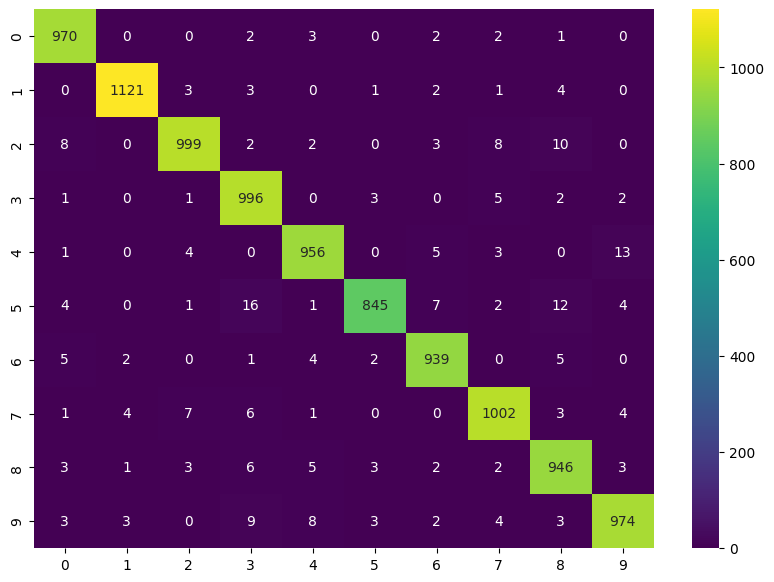

Modelo con 512 neuronas en la capa oculta
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3
TP: 991, FP: 19, FN: 19
8
TP: 958, FP: 31, FN: 16


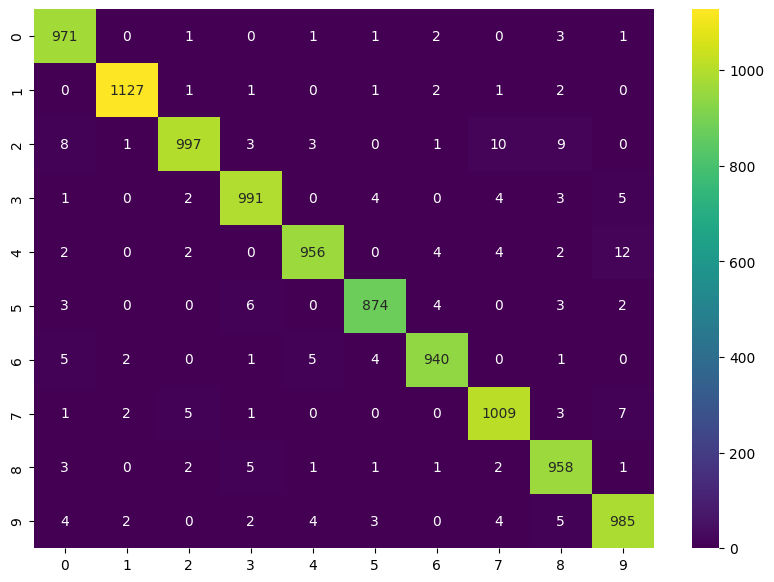

Modelo con 1024 neuronas en la capa oculta
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3
TP: 994, FP: 28, FN: 16
8
TP: 953, FP: 19, FN: 21


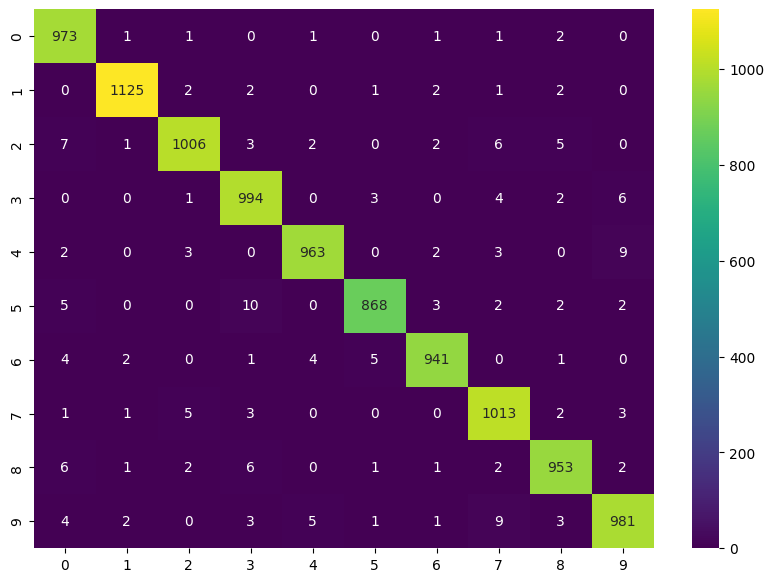

In [ ]:
# dict_pred_nneu = {}
lst_FP_FN = []

for neu, _model in zip(lst_neuronas, lst_mod_nneu):
    print(f'Modelo con {neu} neuronas en la capa oculta')
    y_predict = _model.predict(X_test)

    y_pred = []
    for i in range(y_predict.shape[0]):
        maximum = np.argmax(y_predict[i])
        y_pred.append(maximum)

    conf_mat = confusion_matrix(y_test, y_pred)

    print('3')
    TP_p = conf_mat[3, 3]
    FP_p = conf_mat[:,3].sum() - TP_p
    FN_p = conf_mat[3,:].sum() - TP_p
    print(f'TP: {TP_p}, FP: {FP_p}, FN: {FN_p}')

    print('8')
    TP_s = conf_mat[8, 8]
    FP_s = conf_mat[:,8].sum() - TP_s
    FN_s = conf_mat[8,:].sum() - TP_s
    print(f'TP: {TP_s}, FP: {FP_s}, FN: {FN_s}')
    metrics = {'Neuronas': {neu}, 'TP_3': FP_p, 'FN_3': FN_p, 'TP_8': FP_s, 'FN_8': FN_s}
    lst_FP_FN.append(metrics)

    plt.figure(figsize=(10, 7))
    # "Blues"
    sbn.heatmap(conf_mat, cmap='viridis', annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names)
    plt.show()

df_FP_FN = pd.DataFrame(lst_FP_FN)

In [ ]:
df_FP_FN

,Neuronas,TP_3,FN_3,TP_8,FN_8
0,{128},45,14,40,28
1,{512},19,19,31,16
2,{1024},28,16,19,21


# 8: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la mejor red neuronal de la sección 2 y entrenarla variando el número de épocas:

1. Con 15 epochs
2. Con 30 epochs
3. Con 45 epochs


In [ ]:
def train_model_epoch(optimizer, epoch, X_train, y_train):
    model = Sequential()
    model.add(Input(shape=(28, 28)))
    model.add(Flatten())
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer = optimizer,
        loss = 'sparse_categorical_crossentropy',
        metrics=['accuracy']
        )

    history = model.fit(
        X_train, y_train,
        validation_split = 0.2,
        epochs = epoch,
        batch_size = 64
    )
    return model, history

In [ ]:
optimizer = 'SGD'
lst_epoch = [15, 30, 45]

In [ ]:
dict_epochmodels = {}
for epoch in lst_epoch:
    print(f'Modelo entrenado con {epoch} épocas')
    model_, history_ = train_model_epoch(optimizer, epoch, X_train, y_train)
    dict_epochmodels[epoch] = [model_, history_]

Modelo entrenado con 15 épocas
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6938 - loss: 1.1887 - val_accuracy: 0.8769 - val_loss: 0.4503
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8887 - loss: 0.3965 - val_accuracy: 0.9061 - val_loss: 0.3248
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9084 - loss: 0.3216 - val_accuracy: 0.9201 - val_loss: 0.2814
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9189 - loss: 0.2843 - val_accuracy: 0.9268 - val_loss: 0.2545
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9262 - loss: 0.2575 - val_accuracy: 0.9323 - val_loss: 0.2342
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9320 - loss: 0.2357 - val_accuracy: 0.9373 - val_loss: 0.2177
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9377 - loss: 0.2173 - val_accuracy: 0.9421 - val_loss: 0.2037
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9425 - 

In [ ]:
lst_hist_epochm = []
for key in dict_epochmodels:
    mod = dict_epochmodels[key]
    hist = mod[1]
    lst_hist_epochm.append(hist.history)

In [ ]:
df_met_epoch = get_df_metrics(lst_hist_epochm, lst_epoch)
display(df_met_epoch)

,activation function,accuracy,loss,val_accuracy,val_loss
0,15,0.962937,0.129517,0.960750,0.139980
1,30,0.983229,0.062084,0.968333,0.105171
2,45,0.990375,0.038732,0.971667,0.103942


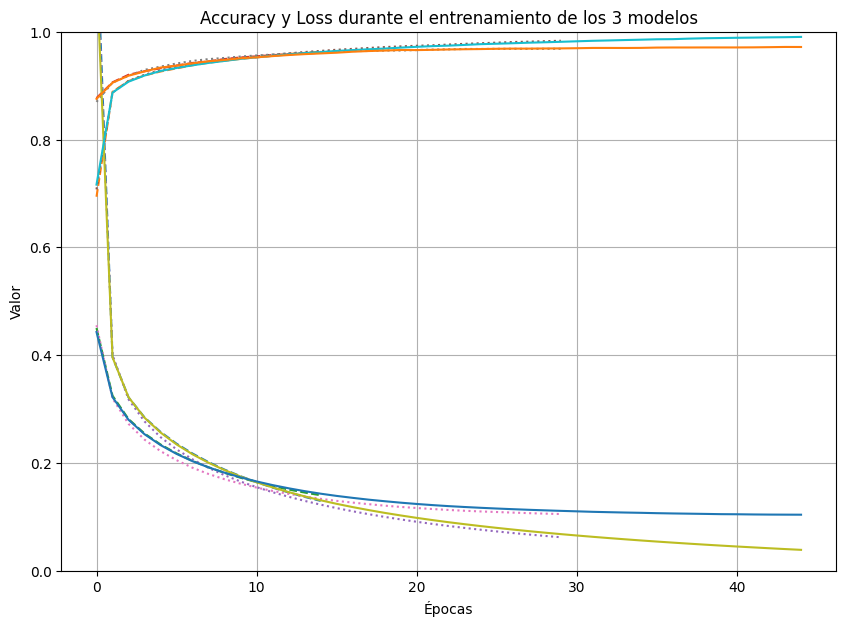

In [ ]:
fig_epoch = plt.figure(figsize=(10, 7))
ax_epoch = plt.subplot(111)

for opt, hist, sline in zip(lst_epoch, lst_hist_epochm, lst_style_nneu):
    ax_epoch.plot(hist['loss'], label=f'Training loss {epoch}', linestyle = sline)
    ax_epoch.plot(hist['accuracy'], label=f'Training accuracy {epoch}', linestyle = sline)
    ax_epoch.plot(hist['val_loss'], label=f'Validation loss {epoch}', linestyle = sline)
    ax_epoch.plot(hist['val_accuracy'], label=f'Validation accuracy {epoch}', linestyle = sline)

plt.grid(True)
plt.ylim(0, 1)  # Coloca los límites del eje 'y' entre 0 y 1

plt.title(f'Accuracy y Loss durante el entrenamiento de los {len(lst_epoch)} modelos')
plt.xlabel('Épocas')
plt.ylabel('Valor')

# Shrink current axis by 20%
box_opt = ax_opt.get_position()
ax_opt.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax_opt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

# 9: Early stop
En la sección anterior, cuando se entrena con epócas extras, se identifica que el accuracy ya no aumenta después de un número de epócas. Para evitar el entrenamiento de epócas adicionales se puede implementar una clase denominada callback que una vez alcanzado el 90% de accuracy se detenga el entrenamiento.

In [ ]:
### Código de la función callback para detener el entrenamiento de la red neuronal al 90% de accuracy ###

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.9):
              print("\nAlcanzado el 90% de accuracy, se cancela el entrenamiento!!")
              self.model.stop_training = True

In [ ]:
callbacks = myCallback()

model_callback = tf.keras.models.Sequential(
    [tf.keras.layers.Input(shape=(28,28)),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation='relu'),
     tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    ]
)

model_callback.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_callback.fit(X_train, y_train, epochs=30, callbacks=[callbacks])

Epoch 1/30
1831/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.8794 - loss: 0.4298
Alcanzado el 90% de accuracy, se cancela el entrenamiento!!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.9269 - loss: 0.2566
